# 🔥 Oregon Wildfire Prediction with PyTorch

This notebook trains a neural network to predict **wildfire severity** (total acres burned) and **fire risk classification** (low / medium / high) from historical Oregon fire and weather data spanning 1970–2021.

### Pipeline Overview
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Preprocessing
3. Dataset & DataLoader construction
4. Model architecture (MLP with batch norm + dropout)
5. Training & Validation
6. Evaluation & Feature Importance
7. Inference on new data

## 1. Imports & Setup

In [111]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os, random

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── Scikit-learn (preprocessing & metrics) ────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              mean_absolute_error, r2_score)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.8.0


## 2. Load Data

In [112]:
# ── Update this path if your CSV lives elsewhere ──────────────────────────────
DATA_PATH = 'oregon_fires_weather_merged.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (56280, 31)


,id,fire_year,report_date,county,latitude,longitude,total_acres,odf_acres,fuel_model,fuel_descr,...,WDSP,MXSPD,PRCP,PRCP_30DAY,VPD_PROXY,TEMP_RANGE,FIRE_SEASON,MONTH,DOY,STATION_USED
0,9151,1970,1970-06-15,Tillamook,45.517000,-122.047000,0.05,0.05,X,non-wildland fuel,...,6.9,10.1,0.0,0.0,8.4,10.9,1.0,6.0,166.0,9.999992e+10
1,9152,1970,1970-06-22,Tillamook,45.498172,-122.044483,0.75,0.75,X,non-wildland fuel,...,7.6,15.0,0.0,0.0,18.3,27.0,1.0,6.0,173.0,9.999992e+10
2,9153,1970,1970-06-24,Tillamook,45.748014,-122.044125,10.00,10.00,X,non-wildland fuel,...,7.1,10.1,0.0,0.0,18.6,29.9,1.0,6.0,175.0,9.999992e+10
3,9154,1970,1970-07-04,Tillamook,45.748014,-122.044125,0.05,0.05,F,dense brush,...,7.0,8.0,0.0,0.0,19.2,36.0,1.0,7.0,185.0,9.999992e+10
4,9155,1970,1970-07-06,Tillamook,45.613422,-122.445444,0.05,0.05,F,dense brush,...,7.7,14.0,0.0,0.0,15.3,28.9,1.0,7.0,187.0,9.999992e+10


In [113]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Data Types ===
id                 int64
fire_year          int64
report_date       object
county            object
latitude         float64
longitude        float64
total_acres      float64
odf_acres        float64
fuel_model        object
fuel_descr        object
general_cause     object
fire_name         object
district          object
unit              object
legal             object
LATITUDE         float64
LONGITUDE        float64
TEMP             float64
MAX              float64
MIN              float64
DEWP             float64
WDSP             float64
MXSPD            float64
PRCP             float64
PRCP_30DAY       float64
VPD_PROXY        float64
TEMP_RANGE       float64
FIRE_SEASON      float64
MONTH            float64
DOY              float64
STATION_USED     float64
dtype: object

=== Missing Values ===
county             3
total_acres      119
odf_acres          5
fuel_model       126
fuel_descr       126
legal             13
LATITUDE         234
LONGITUDE        234


## 3. Exploratory Data Analysis

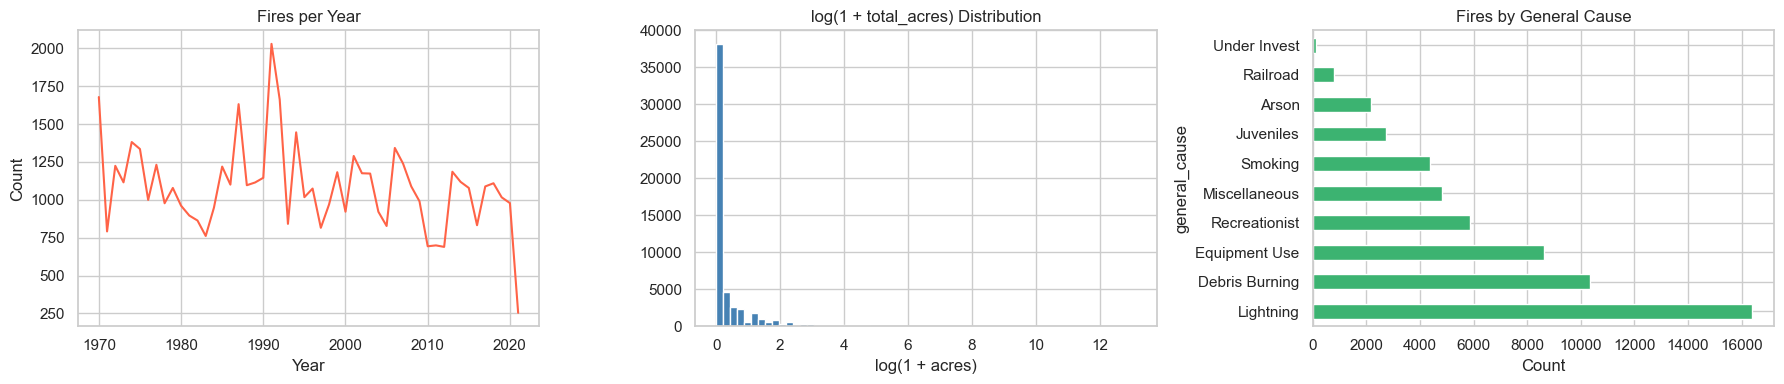

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Fires per year
df.groupby('fire_year').size().plot(ax=axes[0], color='tomato')
axes[0].set_title('Fires per Year'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Count')

# Log-scale acres distribution
log_acres = np.log1p(df['total_acres'].dropna())
axes[1].hist(log_acres, bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('log(1 + total_acres) Distribution')
axes[1].set_xlabel('log(1 + acres)')

# Fires by cause
cause_counts = df['general_cause'].value_counts()
cause_counts.plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Fires by General Cause'); axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

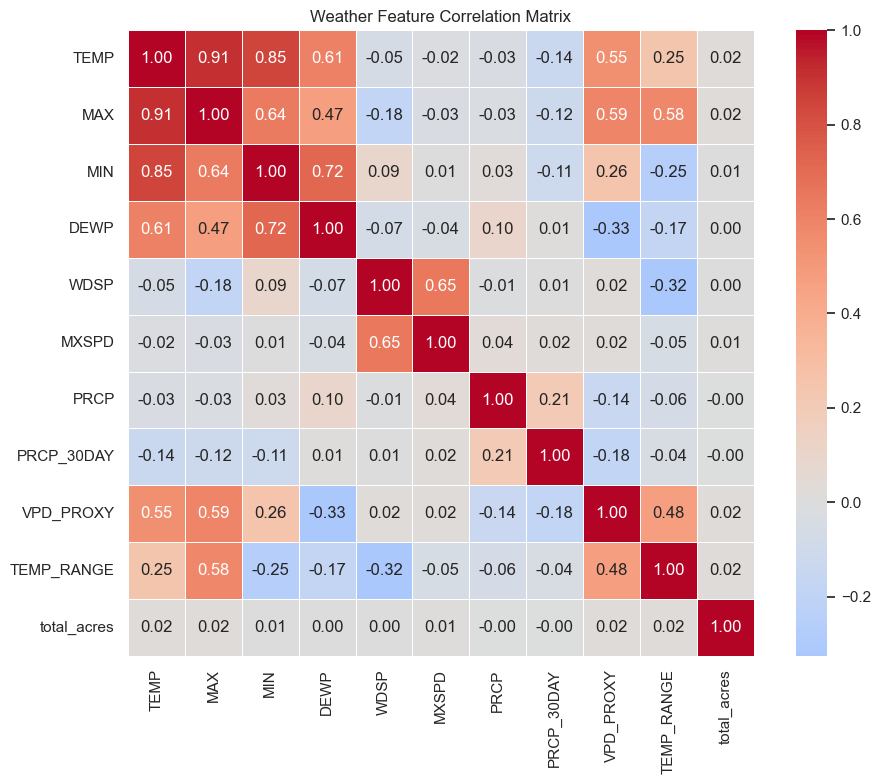

In [115]:
weather_cols = ['TEMP', 'MAX', 'MIN', 'DEWP', 'WDSP', 'MXSPD',
                'PRCP', 'PRCP_30DAY', 'VPD_PROXY', 'TEMP_RANGE']

corr = df[weather_cols + ['total_acres']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Weather Feature Correlation Matrix')
plt.tight_layout()
plt.show()

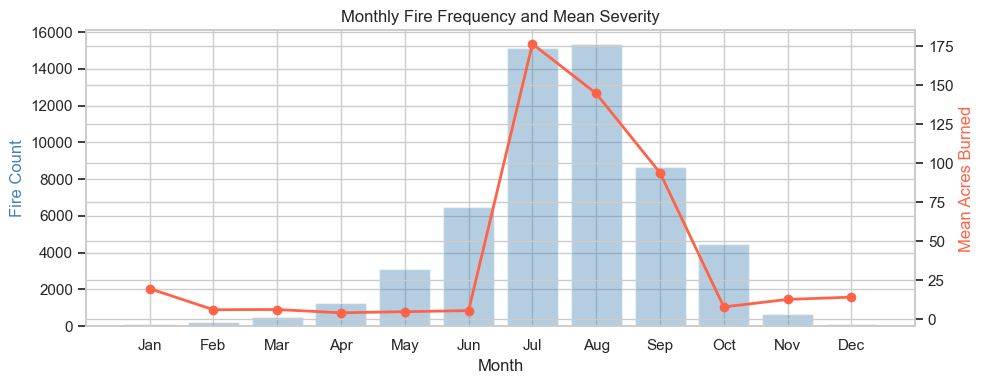

In [116]:
df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')
df['month_num'] = df['report_date'].dt.month

monthly = df.groupby('month_num')['total_acres'].agg(['mean', 'count'])
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(monthly.index, monthly['count'], alpha=0.4, color='steelblue', label='Fire count')
ax2.plot(monthly.index, monthly['mean'], 'o-', color='tomato', lw=2, label='Mean acres')
ax1.set_xlabel('Month'); ax1.set_ylabel('Fire Count', color='steelblue')
ax2.set_ylabel('Mean Acres Burned', color='tomato')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Monthly Fire Frequency and Mean Severity')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

In [117]:
df2 = df.copy()

# ── Derived date features ──────────────────────────────────────────────────────
df2['month'] = df2['report_date'].dt.month.fillna(df2['MONTH'])
df2['doy']   = df2['report_date'].dt.dayofyear.fillna(df2['DOY'])

# Cyclical encoding of month and day-of-year avoids ordinal discontinuity
df2['month_sin'] = np.sin(2 * np.pi * df2['month'] / 12)
df2['month_cos'] = np.cos(2 * np.pi * df2['month'] / 12)
df2['doy_sin']   = np.sin(2 * np.pi * df2['doy'] / 365)
df2['doy_cos']   = np.cos(2 * np.pi * df2['doy'] / 365)

# ── Encode categorical variables ───────────────────────────────────────────────
le_cause      = LabelEncoder()
le_fuel       = LabelEncoder()
le_county     = LabelEncoder()

df2['cause_enc']  = le_cause.fit_transform(df2['general_cause'].fillna('Unknown'))
df2['fuel_enc']   = le_fuel.fit_transform(df2['fuel_model'].fillna('X'))
df2['county_enc'] = le_county.fit_transform(df2['county'].fillna('Unknown'))

# ── Target: three-class fire severity ─────────────────────────────────────────
# Low: < 1 acre  |  Medium: 1–100 acres  |  High: > 100 acres
def severity_class(acres):
    if pd.isna(acres): return np.nan
    if acres < 1:   return 0  # Low
    if acres <= 100: return 1  # Medium
    return 2                   # High

df2['severity'] = df2['total_acres'].apply(severity_class)
df2['log_acres'] = np.log1p(df2['total_acres'])  # regression target

severity_labels = {0: 'Low (<1 ac)', 1: 'Medium (1–100 ac)', 2: 'High (>100 ac)'}
print('Class distribution:')
print(df2['severity'].value_counts().rename(severity_labels))

Class distribution:
severity
Low (<1 ac)          45390
Medium (1–100 ac)     9859
High (>100 ac)         912
Name: count, dtype: int64


In [118]:
# ── Select model features ──────────────────────────────────────────────────────
FEATURE_COLS = [
    # Weather
    'TEMP', 'MAX', 'MIN', 'DEWP', 'WDSP', 'MXSPD',
    'PRCP', 'PRCP_30DAY', 'VPD_PROXY', 'TEMP_RANGE',
    # Spatial
    'latitude', 'longitude',
    # Temporal (cyclical)
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    # Categorical (encoded)
    'cause_enc', 'fuel_enc', 'county_enc',
    # Contextual
    'fire_year', 'FIRE_SEASON',
]

TARGET_CLF = 'severity'   # classification
TARGET_REG = 'log_acres'  # regression

# Drop rows with any missing values in the selected columns
mask = df2[FEATURE_COLS + [TARGET_CLF, TARGET_REG]].notnull().all(axis=1)
df_clean = df2[mask].reset_index(drop=True)
print(f'Clean rows: {len(df_clean):,} / {len(df2):,}')

Clean rows: 54,360 / 56,280


## 5. Train / Validation / Test Split

In [119]:
X = df_clean[FEATURE_COLS].values.astype(np.float32)
y_clf = df_clean[TARGET_CLF].values.astype(np.int64)
y_reg = df_clean[TARGET_REG].values.astype(np.float32)

# 70 / 15 / 15 split (stratified on severity class)
X_tmp, X_test, y_clf_tmp, y_clf_test, y_reg_tmp, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.15, random_state=SEED, stratify=y_clf)

X_train, X_val, y_clf_train, y_clf_val, y_reg_train, y_reg_val = train_test_split(
    X_tmp, y_clf_tmp, y_reg_tmp, test_size=0.15/0.85, random_state=SEED, stratify=y_clf_tmp)

print(f'Train : {X_train.shape[0]:>7,}')
print(f'Val   : {X_val.shape[0]:>7,}')
print(f'Test  : {X_test.shape[0]:>7,}')

# ── Normalise features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Train :  38,051
Val   :   8,155
Test  :   8,154


## 6. PyTorch Dataset & DataLoaders

In [120]:
class WildfireDataset(Dataset):
    """Returns (features, severity_class, log_acres) tuples."""

    def __init__(self, X, y_clf, y_reg):
        self.X     = torch.tensor(X,     dtype=torch.float32)
        self.y_clf = torch.tensor(y_clf, dtype=torch.long)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)

    def __len__(self):  return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_clf[idx], self.y_reg[idx]


# ── Weighted sampler to handle class imbalance ────────────────────────────────
class_counts = np.bincount(y_clf_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_clf_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH = 256

train_ds = WildfireDataset(X_train, y_clf_train, y_reg_train)
val_ds   = WildfireDataset(X_val,   y_clf_val,   y_reg_val)
test_ds  = WildfireDataset(X_test,  y_clf_test,  y_reg_test)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,    num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,    num_workers=0)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 149  |  Val batches: 32


## 7. Model Architecture

A **multi-task MLP** that shares a common trunk and branches into:
- A **classification head** (3-class fire severity)
- A **regression head** (log acres burned)

In [121]:
class WildfireNet(nn.Module):
    """
    Multi-task neural network for wildfire prediction.
    Shared trunk → classification head + regression head.
    """

    def __init__(self, n_features: int, n_classes: int = 3,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()

        # ── Shared trunk ──────────────────────────────────────────────────────
        layers = []
        in_dim = n_features
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        self.trunk = nn.Sequential(*layers)

        # ── Task heads ────────────────────────────────────────────────────────
        self.clf_head = nn.Sequential(
            nn.Linear(in_dim, 32), nn.GELU(),
            nn.Linear(32, n_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Linear(in_dim, 32), nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        z = self.trunk(x)
        return self.clf_head(z), self.reg_head(z).squeeze(-1)


model = WildfireNet(n_features=len(FEATURE_COLS)).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

WildfireNet(
  (trunk): Sequential(
    (0): Linear(in_features=21, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
  )
  (clf_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
  (reg_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(app

## 8. Training

In [122]:
# ── Loss functions ────────────────────────────────────────────────────────────
# Class weights inversely proportional to frequency
clf_weights = torch.tensor(class_weights / class_weights.sum() * len(class_counts),
                           dtype=torch.float32).to(DEVICE)
criterion_clf = nn.CrossEntropyLoss(weight=clf_weights)
criterion_reg = nn.HuberLoss()   # robust to extreme-acreage outliers

# ── Optimiser & scheduler ─────────────────────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

# ── Multi-task loss weighting ─────────────────────────────────────────────────
LAMBDA_CLF = 1.0
LAMBDA_REG = 0.5

EPOCHS     = 50
PATIENCE   = 10  # early stopping

In [123]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = clf_loss_sum = reg_loss_sum = correct = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_clf_b, y_reg_b in loader:
            X_b      = X_b.to(DEVICE)
            y_clf_b  = y_clf_b.to(DEVICE)
            y_reg_b  = y_reg_b.to(DEVICE)

            logits, reg_pred = model(X_b)

            loss_clf = criterion_clf(logits, y_clf_b)
            loss_reg = criterion_reg(reg_pred, y_reg_b)
            loss     = LAMBDA_CLF * loss_clf + LAMBDA_REG * loss_reg

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss    += loss.item()     * len(X_b)
            clf_loss_sum  += loss_clf.item() * len(X_b)
            reg_loss_sum  += loss_reg.item() * len(X_b)
            preds  = logits.argmax(dim=1)
            correct += (preds == y_clf_b).sum().item()
            total   += len(X_b)

    n = total
    return total_loss/n, clf_loss_sum/n, reg_loss_sum/n, correct/n


# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss = float('inf')
patience_ctr  = 0
best_state    = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, _, _, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, _, _, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
              f'Val loss {vl_loss:.4f} acc {vl_acc:.3f}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stop at epoch {epoch}')
        break

# Restore best weights
model.load_state_dict(best_state)
print(f'\nBest validation loss: {best_val_loss:.4f}')

Epoch   1/50 | Train loss 1.2754 acc 0.354 | Val loss 2.1843 acc 0.026
Epoch   5/50 | Train loss 0.9188 acc 0.424 | Val loss 1.9972 acc 0.071
Epoch  10/50 | Train loss 0.7850 acc 0.480 | Val loss 1.9166 acc 0.103
Epoch  15/50 | Train loss 0.7018 acc 0.521 | Val loss 1.9562 acc 0.118
Epoch  20/50 | Train loss 0.6453 acc 0.541 | Val loss 1.9840 acc 0.130
Epoch  25/50 | Train loss 0.6014 acc 0.563 | Val loss 2.0440 acc 0.137

Early stop at epoch 28

Best validation loss: 1.8968


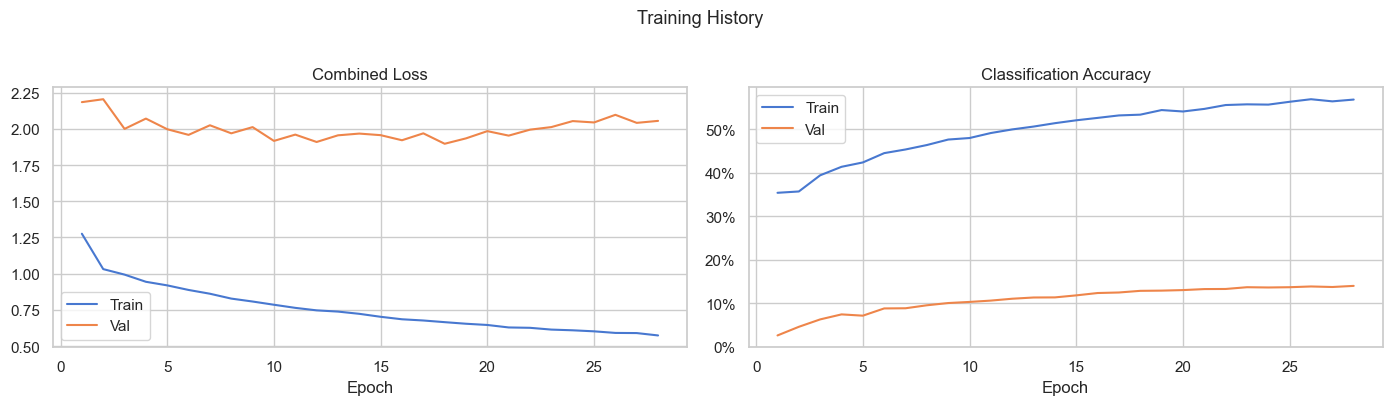

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val')
axes[0].set_title('Combined Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_ran, history['train_acc'], label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val')
axes[1].set_title('Classification Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend()

plt.suptitle('Training History', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Evaluation on the Test Set

In [125]:
model.eval()
all_preds_clf, all_true_clf = [], []
all_preds_reg, all_true_reg = [], []

with torch.no_grad():
    for X_b, y_clf_b, y_reg_b in test_loader:
        logits, reg_pred = model(X_b.to(DEVICE))
        all_preds_clf.extend(logits.argmax(1).cpu().numpy())
        all_true_clf.extend(y_clf_b.numpy())
        all_preds_reg.extend(reg_pred.cpu().numpy())
        all_true_reg.extend(y_reg_b.numpy())

all_preds_clf = np.array(all_preds_clf)
all_true_clf  = np.array(all_true_clf)
all_preds_reg = np.array(all_preds_reg)
all_true_reg  = np.array(all_true_reg)

=== Classification Report (Severity) ===
                   precision    recall  f1-score   support

      Low (<1 ac)       0.00      0.00      0.00      6585
Medium (1–100 ac)       0.16      0.66      0.26      1439
   High (>100 ac)       0.04      0.65      0.07       130

         accuracy                           0.13      8154
        macro avg       0.07      0.43      0.11      8154
     weighted avg       0.03      0.13      0.05      8154



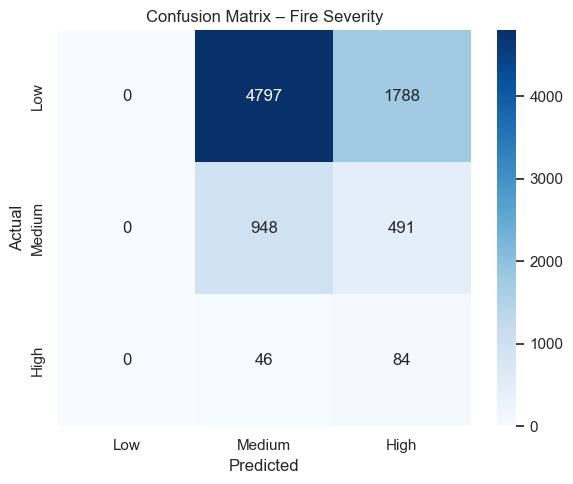

In [126]:
print('=== Classification Report (Severity) ===')
print(classification_report(
    all_true_clf, all_preds_clf,
    target_names=['Low (<1 ac)', 'Medium (1–100 ac)', 'High (>100 ac)']))

cm = confusion_matrix(all_true_clf, all_preds_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix – Fire Severity')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Regression (log-acres) — MAE: 1.0647  |  R²: -1.3897
Regression (raw acres) — MAE: 118.8 acres


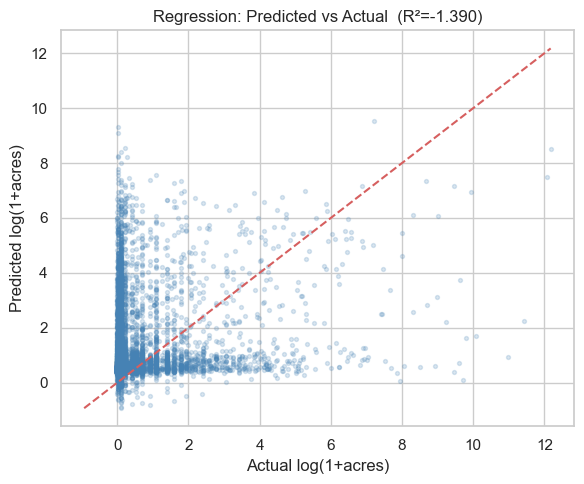

In [127]:
mae  = mean_absolute_error(all_true_reg, all_preds_reg)
r2   = r2_score(all_true_reg, all_preds_reg)

# Convert from log space back to acres for interpretability
true_acres = np.expm1(all_true_reg)
pred_acres = np.expm1(all_preds_reg)
mae_acres  = mean_absolute_error(true_acres, pred_acres)

print(f'Regression (log-acres) — MAE: {mae:.4f}  |  R²: {r2:.4f}')
print(f'Regression (raw acres) — MAE: {mae_acres:.1f} acres')

# Scatter: predicted vs actual
plt.figure(figsize=(6, 5))
plt.scatter(all_true_reg, all_preds_reg, alpha=0.2, s=8, color='steelblue')
lims = [min(all_true_reg.min(), all_preds_reg.min()),
        max(all_true_reg.max(), all_preds_reg.max())]
plt.plot(lims, lims, 'r--', lw=1.5)
plt.xlabel('Actual log(1+acres)'); plt.ylabel('Predicted log(1+acres)')
plt.title(f'Regression: Predicted vs Actual  (R²={r2:.3f})')
plt.tight_layout()
plt.show()

## 10. Feature Importance via Permutation

Computing permutation importance (this may take ~1 minute)…


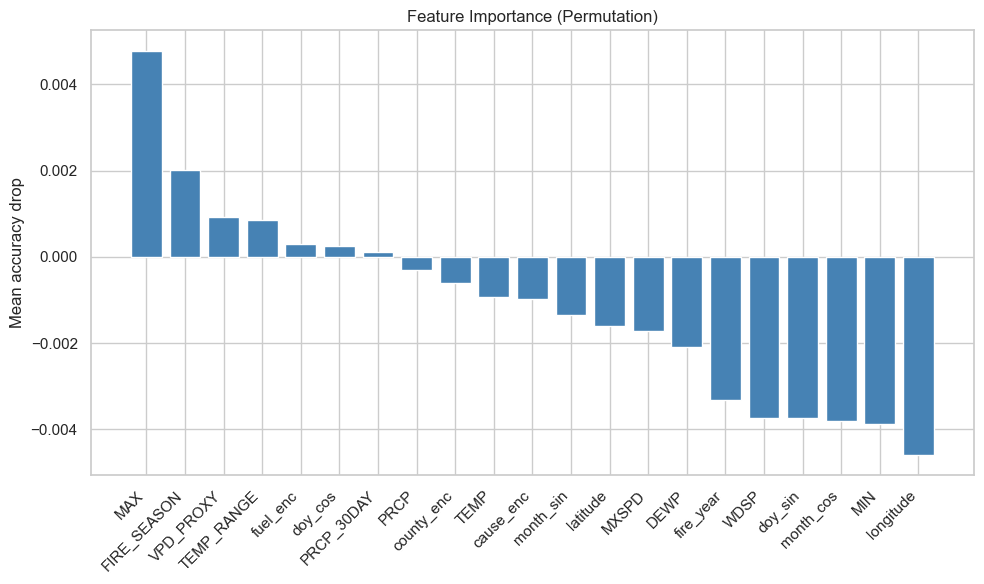

In [128]:
def permutation_importance(model, loader, n_repeats=3):
    """Measure drop in accuracy when each feature is shuffled."""
    model.eval()

    # Baseline accuracy
    correct = total = 0
    with torch.no_grad():
        for X_b, y_b, _ in loader:
            logits, _ = model(X_b.to(DEVICE))
            correct += (logits.argmax(1).cpu() == y_b).sum().item()
            total   += len(y_b)
    base_acc = correct / total

    importances = []
    for feat_idx in range(X_val.shape[1]):
        drop = []
        for _ in range(n_repeats):
            X_perm = torch.tensor(X_val.copy(), dtype=torch.float32)
            idx    = torch.randperm(len(X_perm))
            X_perm[:, feat_idx] = X_perm[idx, feat_idx]

            perm_ds     = WildfireDataset(X_perm.numpy(), y_clf_val, y_reg_val)
            perm_loader = DataLoader(perm_ds, batch_size=BATCH, shuffle=False)

            c = t = 0
            with torch.no_grad():
                for X_b, y_b, _ in perm_loader:
                    logits, _ = model(X_b.to(DEVICE))
                    c += (logits.argmax(1).cpu() == y_b).sum().item()
                    t += len(y_b)
            drop.append(base_acc - c / t)
        importances.append(np.mean(drop))

    return np.array(importances)


print('Computing permutation importance (this may take ~1 minute)…')
imp = permutation_importance(model, val_loader, n_repeats=2)

order = np.argsort(imp)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(FEATURE_COLS)), imp[order], color='steelblue')
plt.xticks(range(len(FEATURE_COLS)), [FEATURE_COLS[i] for i in order], rotation=45, ha='right')
plt.ylabel('Mean accuracy drop')
plt.title('Feature Importance (Permutation)')
plt.tight_layout()
plt.show()

## 11. Save & Load Model

In [129]:
import pickle

# Save model weights
torch.save(model.state_dict(), 'oregon_wildfire_model.pt')

# Save scaler + label encoders for later inference
artifacts = {
    'scaler':       scaler,
    'le_cause':     le_cause,
    'le_fuel':      le_fuel,
    'le_county':    le_county,
    'feature_cols': FEATURE_COLS,
}
with open('oregon_wildfire_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Model and artifacts saved.')

Model and artifacts saved.


In [130]:
# ── To reload in a fresh session ──────────────────────────────────────────────
loaded_model = WildfireNet(n_features=len(FEATURE_COLS)).to(DEVICE)
loaded_model.load_state_dict(torch.load('oregon_wildfire_model.pt', map_location=DEVICE))
loaded_model.eval()
print('Model loaded successfully.')

Model loaded successfully.


## 12. Inference on New Data

Use this cell to predict fire severity for a new event.

In [131]:
import pickle

with open('oregon_wildfire_artifacts.pkl', 'rb') as f:
    arts = pickle.load(f)

def predict_fire(raw_input: dict) -> dict:
    """
    Predict severity class and estimated acres for a new fire event.

    Parameters
    ----------
    raw_input : dict with keys matching the data schema, e.g.:
        {
            'general_cause': 'Lightning',
            'fuel_model':    'C',
            'county':        'Deschutes',
            'latitude':      44.0,
            'longitude':    -121.3,
            'fire_year':     2024,
            'month':         8,
            'doy':           220,
            'TEMP': 85, 'MAX': 95, 'MIN': 65, 'DEWP': 30,
            'WDSP': 12, 'MXSPD': 25, 'PRCP': 0.0,
            'PRCP_30DAY': 0.1, 'VPD_PROXY': 35, 'TEMP_RANGE': 30,
            'FIRE_SEASON': 1.0,
        }
    """
    scaler    = arts['scaler']
    le_cause  = arts['le_cause']
    le_fuel   = arts['le_fuel']
    le_county = arts['le_county']
    feat_cols = arts['feature_cols']

    # Encode categoricals
    cause_enc  = le_cause.transform([raw_input.get('general_cause', 'Unknown')])[0]
    fuel_enc   = le_fuel.transform([raw_input.get('fuel_model', 'X')])[0]
    county_enc = le_county.transform([raw_input.get('county', 'Unknown')])[0]

    month = raw_input.get('month', 7)
    doy   = raw_input.get('doy', 200)

    row = {
        'TEMP':         raw_input.get('TEMP', 70),
        'MAX':          raw_input.get('MAX', 85),
        'MIN':          raw_input.get('MIN', 55),
        'DEWP':         raw_input.get('DEWP', 40),
        'WDSP':         raw_input.get('WDSP', 8),
        'MXSPD':        raw_input.get('MXSPD', 15),
        'PRCP':         raw_input.get('PRCP', 0),
        'PRCP_30DAY':   raw_input.get('PRCP_30DAY', 0.5),
        'VPD_PROXY':    raw_input.get('VPD_PROXY', 20),
        'TEMP_RANGE':   raw_input.get('TEMP_RANGE', 30),
        'latitude':     raw_input.get('latitude', 44.0),
        'longitude':    raw_input.get('longitude', -120.5),
        'month_sin':    np.sin(2 * np.pi * month / 12),
        'month_cos':    np.cos(2 * np.pi * month / 12),
        'doy_sin':      np.sin(2 * np.pi * doy / 365),
        'doy_cos':      np.cos(2 * np.pi * doy / 365),
        'cause_enc':    cause_enc,
        'fuel_enc':     fuel_enc,
        'county_enc':   county_enc,
        'fire_year':    raw_input.get('fire_year', 2024),
        'FIRE_SEASON':  raw_input.get('FIRE_SEASON', 1.0),
    }

    X_new = np.array([[row[c] for c in feat_cols]], dtype=np.float32)
    X_new = scaler.transform(X_new)

    loaded_model.eval()
    with torch.no_grad():
        logits, log_acres = loaded_model(torch.tensor(X_new, dtype=torch.float32).to(DEVICE))

    probs   = torch.softmax(logits, dim=1).cpu().numpy()[0]
    cls_idx = int(probs.argmax())
    class_names = ['Low (<1 acre)', 'Medium (1–100 acres)', 'High (>100 acres)']

    return {
        'severity_class':  class_names[cls_idx],
        'probabilities':   {class_names[i]: round(float(probs[i]), 4) for i in range(3)},
        'estimated_acres': round(float(np.expm1(log_acres.cpu().item())), 2),
    }


# ── Example prediction ────────────────────────────────────────────────────────
example = {
    'general_cause': 'Lightning',
    'fuel_model': 'C',
    'county': 'Deschutes',
    'latitude': 44.0, 'longitude': -121.3,
    'fire_year': 2024, 'month': 8, 'doy': 220,
    'TEMP': 88, 'MAX': 98, 'MIN': 68, 'DEWP': 25,
    'WDSP': 14, 'MXSPD': 28, 'PRCP': 0.0,
    'PRCP_30DAY': 0.05, 'VPD_PROXY': 40, 'TEMP_RANGE': 30,
    'FIRE_SEASON': 1.0,
}

result = predict_fire(example)
print('Prediction Result:')
for k, v in result.items():
    print(f'  {k}: {v}')

Prediction Result:
  severity_class: High (>100 acres)
  probabilities: {'Low (<1 acre)': 0.0001, 'Medium (1–100 acres)': 0.0011, 'High (>100 acres)': 0.9988}
  estimated_acres: 14931.35


---
## 13. Forward-Looking Predictions → ArcGIS

This section generates **genuinely new, forward-looking fire predictions** — not historical records.

### How it works
1. Build a **spatial grid** of candidate fire locations across Oregon (lat/lon fishnet derived from the training data's geographic envelope)
2. For each grid cell, construct **scenario weather inputs** by sampling climatological weather statistics learned from the training data (mean ± std per county/month), representing plausible future conditions
3. Run every grid cell through the trained model to get predicted severity class, probability scores, and estimated acres
4. Export as **GeoJSON** for ArcGIS Online and a **Shapefile** for ArcGIS Pro

> **Note on interpretation:** These are *conditional severity* predictions — given that a fire ignites at this location under these weather conditions, how bad is it predicted to be? They are not ignition probability predictions. Points with `prob_high > 0.5` represent locations where the model expects extreme fire behaviour under the scenario weather.

### 13a. Learn Climatological Weather Profiles per County

In [ ]:
# ── Build per-county climatological weather statistics from training data ──────
# We use the peak fire season (July–September) as the scenario month

WEATHER_COLS = ['TEMP', 'MAX', 'MIN', 'DEWP', 'WDSP', 'MXSPD',
                'PRCP', 'PRCP_30DAY', 'VPD_PROXY', 'TEMP_RANGE']

SCENARIO_MONTH = 8        # August — peak fire season
SCENARIO_DOY   = 220      # ~August 8
SCENARIO_YEAR  = 2021     # forward-looking year

# Filter training data to fire season months (June–October)
peak_df = df_clean[df_clean['month'].between(6, 10)].copy()

# Per-county mean and std for each weather variable
county_weather_mean = peak_df.groupby('county')[WEATHER_COLS].mean()
county_weather_std  = peak_df.groupby('county')[WEATHER_COLS].std().fillna(0)

# Per-county centroid (representative lat/lon)
county_centroids = peak_df.groupby('county')[['latitude', 'longitude']].mean()

# Most common fuel model and cause per county (used as representative scenario)
county_fuel  = peak_df.groupby('county')['fuel_model'].agg(lambda x: x.mode()[0])
county_cause = peak_df.groupby('county')['general_cause'].agg(lambda x: x.mode()[0])

print(f'Counties with climate profiles: {len(county_weather_mean)}')
county_weather_mean[['TEMP', 'MAX', 'VPD_PROXY', 'PRCP_30DAY']].round(1)

Counties with climate profiles: 36


,TEMP,MAX,VPD_PROXY,PRCP_30DAY
county,,,,
Baker,69.2,88.2,23.1,0.6
Benton,65.4,83.2,16.2,0.6
Clackamas,68.1,82.9,20.9,0.3
Clatsop,68.4,81.6,16.8,0.5
Columbia,67.6,82.1,16.5,0.5
Coos,64.7,78.1,15.9,0.4
Crook,70.1,85.9,27.0,0.2
Curry,60.9,74.1,18.0,0.8
Deschutes,65.7,84.9,25.7,0.4


### 13b. Build the Prediction Grid

For each county we generate **multiple weather scenarios** spanning the plausible range:
- **Average** conditions (μ)
- **Hot & dry** conditions (μ + 1σ temp/VPD, μ − 1σ precip) — elevated risk
- **Extreme** conditions (μ + 2σ temp/VPD, near-zero precip) — worst-case

In [133]:
import itertools

SCENARIOS = {
    'average':   {'temp_sigma': 0.0,  'vpd_sigma': 0.0,  'prcp_sigma':  0.0},
    'hot_dry':   {'temp_sigma': 1.0,  'vpd_sigma': 1.0,  'prcp_sigma': -1.0},
    'extreme':   {'temp_sigma': 2.0,  'vpd_sigma': 2.0,  'prcp_sigma': -2.0},
}

grid_rows = []

for county in county_weather_mean.index:
    # Skip counties with no centroid data
    if county not in county_centroids.index:
        continue

    mu  = county_weather_mean.loc[county]
    sig = county_weather_std.loc[county]
    lat = county_centroids.loc[county, 'latitude']
    lon = county_centroids.loc[county, 'longitude']
    fuel  = county_fuel.get(county, 'C')
    cause = county_cause.get(county, 'Lightning')

    for scenario_name, deltas in SCENARIOS.items():
        ts = deltas['temp_sigma']
        vs = deltas['vpd_sigma']
        ps = deltas['prcp_sigma']

        # Perturb temperature-related variables together
        temp      = mu['TEMP']      + ts * sig['TEMP']
        temp_max  = mu['MAX']       + ts * sig['MAX']
        temp_min  = mu['MIN']       + ts * sig['MIN']
        vpd       = max(0, mu['VPD_PROXY']  + vs * sig['VPD_PROXY'])
        dewp      = mu['DEWP']      - ts * sig['DEWP']   # dewpoint drops when hot
        wdsp      = mu['WDSP']      + ts * sig['WDSP']   # winds often higher in hot events
        mxspd     = mu['MXSPD']     + ts * sig['MXSPD']
        prcp      = max(0, mu['PRCP']      + ps * sig['PRCP'])
        prcp_30   = max(0, mu['PRCP_30DAY']+ ps * sig['PRCP_30DAY'])
        temp_rng  = mu['TEMP_RANGE'] + ts * sig['TEMP_RANGE']

        grid_rows.append({
            'county':       county,
            'scenario':     scenario_name,
            'latitude':     lat,
            'longitude':    lon,
            'fuel_model':   fuel,
            'general_cause':cause,
            'fire_year':    SCENARIO_YEAR,
            'month':        SCENARIO_MONTH,
            'doy':          SCENARIO_DOY,
            'TEMP':         temp,
            'MAX':          temp_max,
            'MIN':          temp_min,
            'DEWP':         dewp,
            'WDSP':         wdsp,
            'MXSPD':        mxspd,
            'PRCP':         prcp,
            'PRCP_30DAY':   prcp_30,
            'VPD_PROXY':    vpd,
            'TEMP_RANGE':   temp_rng,
            'FIRE_SEASON':  1.0,
        })

grid_df = pd.DataFrame(grid_rows)
print(f'Prediction grid: {len(grid_df):,} scenarios ({len(county_weather_mean)} counties × {len(SCENARIOS)} weather scenarios)')
grid_df.head(9)

Prediction grid: 108 scenarios (36 counties × 3 weather scenarios)


,county,scenario,latitude,longitude,fuel_model,general_cause,fire_year,month,doy,TEMP,MAX,MIN,DEWP,WDSP,MXSPD,PRCP,PRCP_30DAY,VPD_PROXY,TEMP_RANGE,FIRE_SEASON
0,Baker,average,44.657131,-117.120801,C,Lightning,2026,8,220,69.210641,88.247340,50.450477,46.136558,5.218554,13.546153,0.025834,0.564693,23.069568,37.797271,1.0
1,Baker,hot_dry,44.657131,-117.120801,C,Lightning,2026,8,220,77.982477,97.451015,59.442414,39.005704,7.279917,18.569433,0.000000,0.000000,30.553468,45.686089,1.0
2,Baker,extreme,44.657131,-117.120801,C,Lightning,2026,8,220,86.754313,106.654690,68.434350,31.874851,9.341280,23.592713,0.000000,0.000000,38.037367,53.574906,1.0
3,Benton,average,44.498739,-122.538797,L,Debris Burning,2026,8,220,65.440652,83.211304,49.055435,49.222391,5.317826,11.849348,0.015703,0.612826,16.218261,34.155870,1.0
4,Benton,hot_dry,44.498739,-122.538797,L,Debris Burning,2026,8,220,72.600865,92.289603,55.626646,42.955116,7.132072,14.909091,0.000000,0.000000,22.491211,42.047686,1.0
5,Benton,extreme,44.498739,-122.538797,L,Debris Burning,2026,8,220,79.761078,101.367903,62.197858,36.687841,8.946319,17.968833,0.000000,0.000000,28.764161,49.939503,1.0
6,Clackamas,average,45.218010,-121.550338,L,Debris Burning,2026,8,220,68.142889,82.864076,53.071261,47.269501,6.415005,12.030254,0.007636,0.329472,20.873387,29.792639,1.0
7,Clackamas,hot_dry,45.218010,-121.550338,L,Debris Burning,2026,8,220,76.790186,93.109848,62.185968,37.811459,9.684639,16.147972,0.000000,0.000000,30.236903,40.396276,1.0
8,Clackamas,extreme,45.218010,-121.550338,L,Debris Burning,2026,8,220,85.437484,103.355619,71.300675,28.353417,12.954274,20.265690,0.000000,0.000000,39.600418,50.999913,1.0


### 13c. Run the Model on Every Grid Scenario

In [134]:
# ── Encode categoricals using the fitted label encoders ───────────────────────
def safe_encode(encoder, values, fallback_label):
    """Encode with fallback for unseen labels."""
    known = set(encoder.classes_)
    return encoder.transform([v if v in known else fallback_label for v in values])

grid_df['cause_enc']  = safe_encode(le_cause,  grid_df['general_cause'], 'Lightning')
grid_df['fuel_enc']   = safe_encode(le_fuel,   grid_df['fuel_model'],    'C')
grid_df['county_enc'] = safe_encode(le_county, grid_df['county'],        le_county.classes_[0])

# ── Build cyclical temporal features ──────────────────────────────────────────
grid_df['month_sin'] = np.sin(2 * np.pi * grid_df['month'] / 12)
grid_df['month_cos'] = np.cos(2 * np.pi * grid_df['month'] / 12)
grid_df['doy_sin']   = np.sin(2 * np.pi * grid_df['doy'] / 365)
grid_df['doy_cos']   = np.cos(2 * np.pi * grid_df['doy'] / 365)

# ── Scale and run through the model ───────────────────────────────────────────
X_grid = grid_df[FEATURE_COLS].values.astype(np.float32)
X_grid_scaled = scaler.transform(X_grid)
X_grid_tensor = torch.tensor(X_grid_scaled, dtype=torch.float32)

model.eval()
grid_logits, grid_reg = [], []

SCORE_BATCH = 512
with torch.no_grad():
    for i in range(0, len(X_grid_tensor), SCORE_BATCH):
        batch = X_grid_tensor[i:i+SCORE_BATCH].to(DEVICE)
        logits, reg = model(batch)
        grid_logits.append(logits.cpu())
        grid_reg.append(reg.cpu())

grid_logits = torch.cat(grid_logits, dim=0)
grid_probs  = torch.softmax(grid_logits, dim=1).numpy()
grid_preds  = grid_logits.argmax(dim=1).numpy()
grid_acres  = np.expm1(torch.cat(grid_reg).numpy())

SEV_LABELS = {0: 'Low', 1: 'Medium', 2: 'High'}

grid_df['pred_severity'] = [SEV_LABELS[p] for p in grid_preds]
grid_df['prob_low']      = np.round(grid_probs[:, 0], 4)
grid_df['prob_medium']   = np.round(grid_probs[:, 1], 4)
grid_df['prob_high']     = np.round(grid_probs[:, 2], 4)
grid_df['est_acres']     = np.round(grid_acres, 2)

print('Prediction summary by scenario:')
print(grid_df.groupby('scenario')['pred_severity'].value_counts().unstack(fill_value=0))

Prediction summary by scenario:
pred_severity  High  Medium
scenario                   
average          18      18
extreme          34       2
hot_dry          28       8


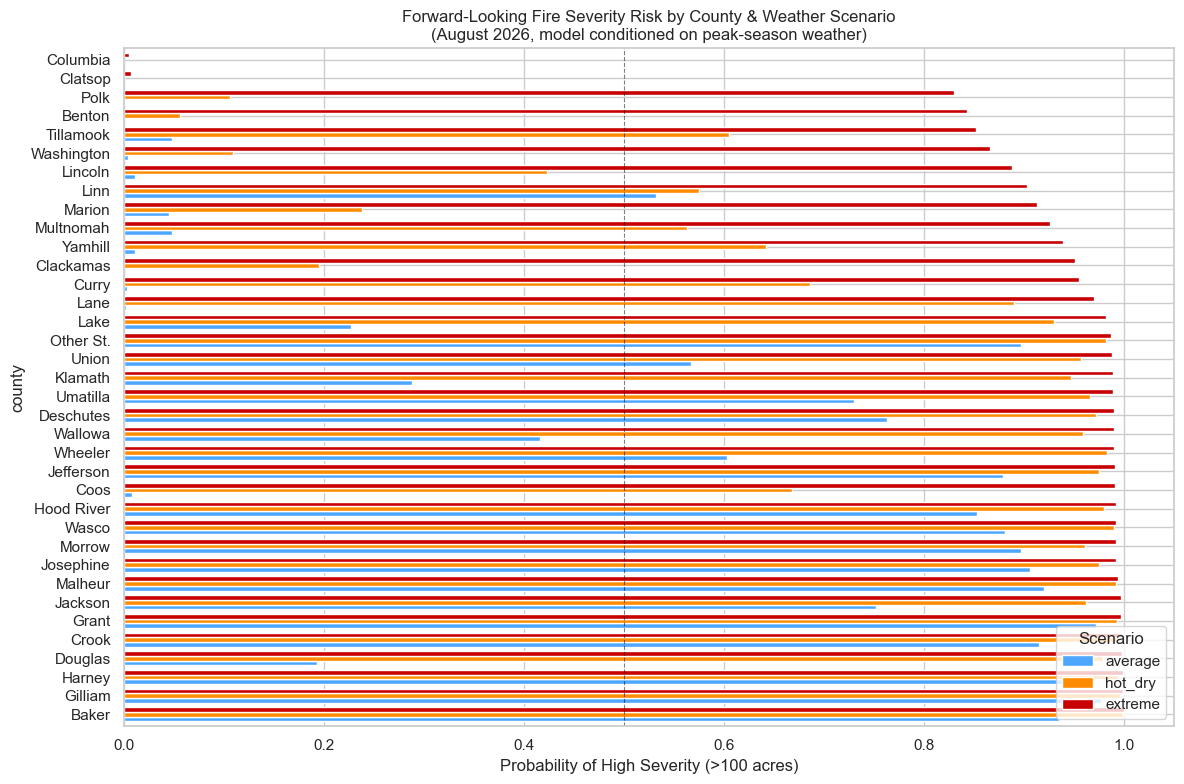

In [135]:
# ── Preview: map prob_high by county across scenarios ─────────────────────────
pivot = grid_df.pivot_table(index='county', columns='scenario',
                             values='prob_high', aggfunc='first')
pivot = pivot[['average', 'hot_dry', 'extreme']].sort_values('extreme', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
pivot.plot(kind='barh', ax=ax,
           color=['#4DA6FF', '#FF8C00', '#C80000'],
           width=0.75)
ax.set_xlabel('Probability of High Severity (>100 acres)')
ax.set_title('Forward-Looking Fire Severity Risk by County & Weather Scenario\n'
             f'(August {SCENARIO_YEAR}, model conditioned on peak-season weather)')
ax.legend(title='Scenario', loc='lower right')
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

### 13d. Export Predictions as ArcGIS-Ready Files

In [136]:
import json

# ── GeoJSON — one feature per county×scenario ─────────────────────────────────
# Each point is at the county centroid; attributes describe the scenario & prediction

RISK_COLOR = {
    'Low':    [255, 235,  59, 200],   # yellow
    'Medium': [255, 140,   0, 210],   # orange
    'High':   [200,   0,   0, 220],   # red
}

features = []
for _, row in grid_df.iterrows():
    sev = str(row['pred_severity'])
    features.append({
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [round(float(row['longitude']), 6),
                            round(float(row['latitude']),  6)]
        },
        'properties': {
            # Identity
            'county':         str(row['county']),
            'scenario':       str(row['scenario']),
            'pred_year':      int(row['fire_year']),
            'pred_month':     int(row['month']),
            # Scenario weather inputs (so analysts can inspect what drove the prediction)
            'scen_temp_f':    round(float(row['TEMP']),       1),
            'scen_max_f':     round(float(row['MAX']),        1),
            'scen_vpd':       round(float(row['VPD_PROXY']),  1),
            'scen_prcp30':    round(float(row['PRCP_30DAY']), 2),
            'scen_wdsp':      round(float(row['WDSP']),       1),
            'fuel_model':     str(row['fuel_model']),
            # Model outputs
            'pred_severity':  sev,
            'prob_low':       float(row['prob_low']),
            'prob_medium':    float(row['prob_medium']),
            'prob_high':      float(row['prob_high']),
            'est_acres':      float(row['est_acres']),
            # ArcGIS display hint (RGBA)
            'display_color':  RISK_COLOR[sev],
        }
    })

geojson_out = {
    'type': 'FeatureCollection',
    'name': f'Oregon Wildfire Forward Predictions {SCENARIO_YEAR}',
    'features': features
}

out_path = f'oregon_wildfire_forward_predictions_{SCENARIO_YEAR}.geojson'
with open(out_path, 'w') as f:
    json.dump(geojson_out, f, indent=2)

print(f'✅ GeoJSON saved → {out_path}')
print(f'   {len(features):,} prediction points ({len(grid_df["county"].unique())} counties × {len(SCENARIOS)} scenarios)')
print()
print('── ArcGIS Online ─────────────────────────────────────────────────────')
print('  Content → New Item → drag & drop the .geojson file')
print('  Publish as Feature Layer → symbolise by pred_severity or prob_high')
print()
print('── ArcGIS Pro ────────────────────────────────────────────────────────')
print('  Map tab → Add Data → browse to .geojson')
print('  Filter by: scenario = \'extreme\' to show worst-case predictions only')

✅ GeoJSON saved → oregon_wildfire_forward_predictions_2026.geojson
   108 prediction points (36 counties × 3 scenarios)

── ArcGIS Online ─────────────────────────────────────────────────────
  Content → New Item → drag & drop the .geojson file
  Publish as Feature Layer → symbolise by pred_severity or prob_high

── ArcGIS Pro ────────────────────────────────────────────────────────
  Map tab → Add Data → browse to .geojson
  Filter by: scenario = 'extreme' to show worst-case predictions only


In [137]:
# ── CSV export (works with ArcGIS Display XY Data, no extra tools needed) ──────
csv_cols = ['county', 'scenario', 'latitude', 'longitude', 'pred_year',
            'month', 'pred_severity', 'prob_low', 'prob_medium', 'prob_high',
            'est_acres', 'scen_temp_f', 'scen_max_f', 'scen_vpd',
            'scen_prcp30', 'scen_wdsp', 'fuel_model', 'general_cause']

# Rename back from internal names for the CSV
csv_df = grid_df.rename(columns={
    'TEMP':       'scen_temp_f',
    'MAX':        'scen_max_f',
    'VPD_PROXY':  'scen_vpd',
    'PRCP_30DAY': 'scen_prcp30',
    'WDSP':       'scen_wdsp',
    'fire_year':  'pred_year',
})

csv_path = f'oregon_wildfire_forward_predictions_{SCENARIO_YEAR}.csv'
csv_df[csv_cols].to_csv(csv_path, index=False)

print(f'✅ CSV saved → {csv_path}')
print('In ArcGIS Pro: Map tab → Add Data → XY Point Data')
print('  X Field = longitude,  Y Field = latitude,  CRS = GCS WGS 1984 (EPSG:4326)')

✅ CSV saved → oregon_wildfire_forward_predictions_2026.csv
In ArcGIS Pro: Map tab → Add Data → XY Point Data
  X Field = longitude,  Y Field = latitude,  CRS = GCS WGS 1984 (EPSG:4326)


In [138]:
# ── Shapefile via GeoPandas (optional) ────────────────────────────────────────
# pip install geopandas
try:
    import geopandas as gpd
    from shapely.geometry import Point

    geometry = [Point(xy) for xy in zip(grid_df['longitude'], grid_df['latitude'])]

    shp_df = grid_df.rename(columns={
        'pred_severity': 'pred_sev',
        'general_cause': 'cause',
        'fuel_model':    'fuel_mdl',
        'prob_medium':   'prob_med',
        'fire_year':     'pred_year',
        'VPD_PROXY':     'scen_vpd',
        'PRCP_30DAY':    'scn_pr30',
        'TEMP':          'scen_tmp',
        'MAX':           'scen_max',
        'WDSP':          'scen_wnd',
    })

    keep = ['county', 'scenario', 'pred_year', 'month', 'latitude', 'longitude',
            'pred_sev', 'prob_low', 'prob_med', 'prob_high', 'est_acres',
            'scen_tmp', 'scen_max', 'scen_vpd', 'scn_pr30', 'scen_wnd', 'fuel_mdl']

    gdf = gpd.GeoDataFrame(shp_df[keep], geometry=geometry, crs='EPSG:4326')
    shp_path = f'oregon_wildfire_forward_predictions_{SCENARIO_YEAR}.shp'
    gdf.to_file(shp_path, driver='ESRI Shapefile')

    print(f'✅ Shapefile saved → {shp_path}')
    print('Tip — in ArcGIS Pro, use Definition Query to filter:')
    print('  scenario = \'extreme\' AND prob_high > 0.4   ← highest-risk locations')

except ImportError:
    print('geopandas not installed — shapefile skipped.')
    print('The GeoJSON and CSV above work without geopandas.')

✅ Shapefile saved → oregon_wildfire_forward_predictions_2026.shp
Tip — in ArcGIS Pro, use Definition Query to filter:
  scenario = 'extreme' AND prob_high > 0.4   ← highest-risk locations


### 13e. Publish Directly to ArcGIS Online

Uploads the forward-prediction GeoJSON as a hosted Feature Layer in your ArcGIS Online org.  
Requires: `pip install arcgis` and your ArcGIS Online credentials.

In [139]:
ARCGIS_USERNAME = 'YOUR_USERNAME'          # ← fill in
ARCGIS_PASSWORD = 'YOUR_PASSWORD'          # ← fill in
ARCGIS_URL      = 'https://www.arcgis.com' # or your Portal URL

try:
    from arcgis.gis import GIS

    gis = GIS(ARCGIS_URL, ARCGIS_USERNAME, ARCGIS_PASSWORD)
    print(f'Signed in as: {gis.properties.user.username}')

    item_props = {
        'title':       f'Oregon Wildfire Forward Predictions {SCENARIO_YEAR}',
        'type':        'GeoJson',
        'tags':        'wildfire, Oregon, machine learning, pytorch, forward prediction',
        'description': (
            f'Forward-looking fire severity predictions for August {SCENARIO_YEAR} '
            'generated by a multi-task PyTorch MLP trained on 1970–2021 ODF fire data. '
            'Three weather scenarios per county: average, hot_dry, extreme. '
            'Attributes include predicted severity class, probability scores, '
            'estimated acres, and the scenario weather inputs.'
        ),
        'snippet': f'Predicted fire severity risk across Oregon counties, August {SCENARIO_YEAR}.',
    }

    geojson_item = gis.content.add(item_props, data=out_path)
    print(f'Uploaded item ID: {geojson_item.id}')

    feature_layer = geojson_item.publish()
    print(f'Published Feature Layer: {feature_layer.url}')
    print(f'View: https://www.arcgis.com/home/item.html?id={feature_layer.id}')

except ImportError:
    print('arcgis package not installed.  Run:  pip install arcgis')
except Exception as e:
    print(f'ArcGIS publish failed: {e}')

ArcGIS publish failed: A general error occurred: Invalid username or password.


### 13f. Recommended ArcGIS Symbology

#### Layer: forward predictions filtered to `scenario = 'extreme'`

| Map type | Field | Settings |
|---|---|---|
| **Unique Values** | `pred_severity` | Low=yellow `#FFE500`, Medium=orange `#FF8C00`, High=red `#C80000` |
| **Graduated Colours** | `prob_high` | Natural Breaks (5 classes), white → dark red ramp |
| **Proportional Symbols** | `est_acres` | Circle, 4–40pt, burnt orange `#D2601A` |
| **Heat Map** | `prob_high` | Kernel density, radius 30km — shows regional hot spots |

#### Definition Queries to try in ArcGIS Pro
```sql
-- Highest-risk locations under extreme scenario
scenario = 'extreme' AND prob_high > 0.5

-- Compare average vs extreme for a specific county
county = 'Deschutes'

-- All locations where even average conditions predict High severity
scenario = 'average' AND pred_severity = 'High'
```

#### Multi-scenario comparison map
Duplicate the layer three times, apply a different Definition Query per copy (`scenario = 'average'`, `'hot_dry'`, `'extreme'`), then place them side-by-side in a **Layout** to show how risk escalates across weather scenarios.

---
## 14. Next Steps & Improvements

| Idea | Details |
|---|---|
| **Ignition probability model** | Build a spatial grid of Oregon, generate no-fire negatives, train a separate binary classifier for P(ignition) — multiply by severity to get expected impact |
| **Sub-county spatial resolution** | Replace county centroids with a 0.1° lat/lon fishnet (~10 km) to get spatially continuous risk maps |
| **Real-time weather** | Replace scenario weather with live NOAA API forecasts for today + 7-day outlook |
| **NDVI / drought index** | Pull MODIS NDVI or PDSI to replace the static fuel_model with a dynamic vegetation dryness signal |
| **Temporal context** | Feed a sliding window of weather history via an LSTM or Transformer |
| **Uncertainty quantification** | Monte Carlo dropout — report a confidence interval on `prob_high` per grid cell |
| **Scheduled ArcGIS refresh** | Run this notebook nightly via a cron job + `arcgis` overwrite to keep the hosted layer current |
| **Elevation & terrain** | Add slope, aspect, and canopy cover from a 30m DEM to improve spatial specificity |